In [3]:
import pandas as pd

df = pd.read_csv("games_dataset.csv")
df_regions = pd.read_csv("team_region_groups.csv")

print("Games Dataset:")
print(df.head())
print("\nTeam Region Groups:")
print(df_regions.head())

Games Dataset:
          game_id   game_date                       team  FGA_2  FGM_2  FGA_3  \
0  game_2022_2011  2021-12-30      georgia_lady_bulldogs     50     22     11   
1  game_2022_2011  2021-12-30                 lsu_tigers     50     24     11   
2  game_2022_2012  2021-12-30            missouri_tigers     43     18     15   
3  game_2022_2012  2021-12-30   south_carolina_gamecocks     55     23     21   
4  game_2022_2013  2021-12-30  tennessee_lady_volunteers     41     20     15   

   FGM_3  FTA  FTM  AST  ...  largest_lead  notD1_incomplete  \
0      5    6    3   14  ...           1.0             False   
1      4   15    8   15  ...          14.0             False   
2      7   16   13   10  ...           8.0             False   
3      6    9    5   15  ...           6.0             False   
4      4   15   10   16  ...          19.0             False   

   OT_length_min_tot  rest_days  attendance  tz_dif_H_E  prev_game_dist  \
0                NaN        9.0      3

In [5]:
# claculating wins and losses using team_score and opponent_team_score,, win: 1(team_score>opponent_team_score; 0 for loss)
df['result'] = df.apply(lambda row: 1 if row['team_score'] > row['opponent_team_score'] else 0, axis=1)
print(df['result'].head(16))

0     0
1     1
2     1
3     0
4     1
5     0
6     0
7     1
8     1
9     0
10    0
11    1
12    0
13    1
14    0
15    1
Name: result, dtype: int64


In [7]:
# Aggregate performance metrics
team_performance = df.groupby('team').agg(
    wins=('result', 'sum'),
    losses=('result', lambda x: len(x) - x.sum()),
    total_points=('team_score', 'sum'),
    total_games=('game_id', 'count'),
    avg_points=('team_score', 'mean'),
    avg_opponent_score=('opponent_team_score', 'mean'),
    avg_FGA_2=('FGA_2', 'mean'),
    avg_FGM_2=('FGM_2', 'mean'),
    avg_FGA_3=('FGA_3', 'mean'),
    avg_FGM_3=('FGM_3', 'mean'),
    avg_FTA=('FTA', 'mean'),
    avg_FTM=('FTM', 'mean'),
    avg_AST=('AST', 'mean'),
    avg_BLK=('BLK', 'mean'),
    avg_STL=('STL', 'mean'),
    avg_TOV=('TOV', 'mean'),
    avg_DREB=('DREB', 'mean'),
    avg_OREB=('OREB', 'mean'),
    avg_F_tech=('F_tech', 'mean'),
    avg_F_personal=('F_personal', 'mean'),
).reset_index()

In [9]:
# team and the region it's found in
team_rankings = pd.merge(team_performance, df_regions, on='team', how='inner')
# Filter for the desired regions(West, North, South  onyl)
filtered_rankings = team_rankings[team_rankings['region'].isin(['West', 'North', 'South'])]

filtered_rankings['ranking_score'] = (
    filtered_rankings['wins'] + 
    0.5 * (filtered_rankings['avg_points'] - filtered_rankings['avg_opponent_score'])
)
# sorting using ranking_score
ranked_teams = filtered_rankings.sort_values(by='ranking_score', ascending=False)
# only top-16
top_teams = ranked_teams.groupby('region').head(16)

top_teams.shape
print(top_teams)

                               team  wins  losses  total_points  total_games  \
99         south_carolina_gamecocks    29       2          2210           31   
28        florida_gulf_coast_eagles    27       2          2258           29   
107               stanford_cardinal    28       3          2287           31   
10                     baylor_bears    27       6          2541           33   
108      stephen_f_austin_ladyjacks    25       4          2160           29   
12                      byu_cougars    24       3          2138           27   
115                 texas_longhorns    26       6          2324           32   
61             louisville_cardinals    25       4          2093           29   
101            south_dakota_coyotes    25       5          2094           30   
36                 gonzaga_bulldogs    26       6          2218           32   
47              iowa_state_cyclones    26       6          2460           32   
117                  toledo_rockets    2

In [13]:
print(top_teams[['team', 'region', 'wins', 'losses', 'avg_points', 'avg_opponent_score', 'ranking_score']])

                               team region  wins  losses  avg_points  \
99         south_carolina_gamecocks  North    29       2   71.290323   
28        florida_gulf_coast_eagles  North    27       2   77.862069   
107               stanford_cardinal   West    28       3   73.774194   
10                     baylor_bears   West    27       6   77.000000   
108      stephen_f_austin_ladyjacks  North    25       4   74.482759   
12                      byu_cougars   West    24       3   79.185185   
115                 texas_longhorns   West    26       6   72.625000   
61             louisville_cardinals  South    25       4   72.172414   
101            south_dakota_coyotes   West    25       5   69.800000   
36                 gonzaga_bulldogs   West    26       6   69.312500   
47              iowa_state_cyclones  South    26       6   76.875000   
117                  toledo_rockets  South    26       4   72.366667   
128                unlv_lady_rebels   West    26       6   75.56

In [15]:
top_teams.to_csv('ranked_teams.csv', index=False)
print("Ranked teams saved in .csv file")

Ranked teams saved in .csv file


In [62]:
import pandas as pd
import numpy as np

dtype_dict = {
    'game_id': 'category',
    'team': 'category',
    'team_home': 'category',
    'team_away': 'category',
    'team_score': 'float32', 
    'opponent_team_score': 'float32', 
    'rest_days': 'float32',
    'travel_dist': 'float32'
}


df_east = pd.read_csv('east_regional_games_to_predict.csv', dtype=dtype_dict)
# df_east.fillna({'team_score': 0, 'opponent_team_score': 0, 'rest_days': 0}, inplace=True)
df_games = pd.read_csv("games_dataset.csv", dtype=dtype_dict)
print(df_games.columns)

Index(['game_id', 'game_date', 'team', 'FGA_2', 'FGM_2', 'FGA_3', 'FGM_3',
       'FTA', 'FTM', 'AST', 'BLK', 'STL', 'TOV', 'TOV_team', 'DREB', 'OREB',
       'F_tech', 'F_personal', 'team_score', 'opponent_team_score',
       'largest_lead', 'notD1_incomplete', 'OT_length_min_tot', 'rest_days',
       'attendance', 'tz_dif_H_E', 'prev_game_dist', 'home_away',
       'home_away_NS', 'travel_dist'],
      dtype='object')


In [96]:
df_home = df_games[['team', 'team_score', 'opponent_team_score', 'rest_days', 'travel_dist']].copy()
df_home.rename(columns={
    'team': 'team_home',
    'team_score': 'home_team_score',
    'opponent_team_score': 'home_opponent_score',
    'rest_days': 'rest_days_Home',
    'travel_dist': 'travel_dist_Home'
}, inplace=True)

df_east = df_east.merge(df_home, on='team_home', how='left')

df_away = df_games[['team', 'team_score', 'opponent_team_score', 'rest_days', 'travel_dist']].copy()
df_away.rename(columns={
    'team': 'team_away',
    'team_score': 'away_team_score',
    'opponent_team_score': 'away_opponent_score',
    'rest_days': 'rest_days_Away',
    'travel_dist': 'travel_dist_Away'
}, inplace=True)

df_east = df_east.merge(df_away, on='team_away', how='left')

# print(df_east.head())
print("finished running")
print(df_east.columns) 

finished running
Index(['game_id', 'description', 'team_home', 'team_away', 'seed_home',
       'seed_away', 'home_away_NS', 'rest_days_Home_x', 'rest_days_Away_x',
       'travel_dist_Home_x', 'travel_dist_Away_x', 'WINNING %',
       'home_team_score_x', 'home_opponent_score_x', 'rest_days_Home_y',
       'travel_dist_Home_y', 'away_team_score_x', 'away_opponent_score_x',
       'rest_days_Away_y', 'travel_dist_Away_y', 'home_win',
       'home_team_score_y', 'home_opponent_score_y', 'rest_days_Home',
       'travel_dist_Home', 'away_team_score_y', 'away_opponent_score_y',
       'rest_days_Away', 'travel_dist_Away'],
      dtype='object')


In [136]:
df_east.fillna({
    'home_team_score': 0,
    'home_opponent_score': 0,
    'rest_days_Home': 0,
    'travel_dist_Home': 0,
    'away_team_score': 0,
    'away_opponent_score': 0,
    'rest_days_Away': 0,
    'travel_dist_Away': 0
}, inplace=True)

print(df_east.isnull().sum())

df_east.to_csv('east_regional_games_cleaned.csv', index=False)
print("finished saving cleaned data")
print(df_east.columns) 

game_id                        0
description                    0
team_home                      0
team_away                      0
seed_home                      0
seed_away                      0
home_away_NS                   0
rest_days_Home_x               0
rest_days_Away_x               0
travel_dist_Home_x             0
travel_dist_Away_x             0
WINNING %                7882844
home_team_score_x              0
home_opponent_score_x          0
rest_days_Home_y          254082
travel_dist_Home_y        398340
away_team_score_x              0
away_opponent_score_x          0
rest_days_Away_y          275096
travel_dist_Away_y       1327110
home_win                       0
home_team_score_y              0
home_opponent_score_y          0
rest_days_Home                 0
travel_dist_Home               0
away_team_score_y              0
away_opponent_score_y          0
rest_days_Away                 0
travel_dist_Away               0
dtype: int64



KeyboardInterrupt



In [70]:
df_east['home_win'] = np.where(df_east['home_team_score'] > df_east['away_opponent_score'], 1, 0)
print(df_east['home_win'])

0       1
1       1
2       1
3       1
4       1
       ..
8857    1
8858    0
8859    1
8860    0
8861    1
Name: home_win, Length: 8862, dtype: int32


In [116]:
# df_east.rename(columns={
#     'rest_days_Home_x': 'rest_days_Home',
#     'rest_days_Away_x': 'rest_days_Away',
#     'travel_dist_Home_x': 'travel_dist_Home',
#     'travel_dist_Away_x': 'travel_dist_Away',
#     'home_team_score_x': 'home_team_score',
#     'home_opponent_score_x': 'home_opponent_score',
#     'away_team_score_x': 'away_team_score',
#     'away_opponent_score_x': 'away_opponent_score'
# }, inplace=True)
# features = ['home_team_score', 'away_opponent_score', 'rest_days_Home_x', 'rest_days_Away_x', 'travel_dist_Home_x', 'travel_dist_Away_x']
# features = ['home_team_score_x', 'away_opponent_score_x', 'rest_days_Home_x', 'rest_days_Away_x', 'travel_dist_Home_x', 'travel_dist_Away_x']
features = ['rest_days_Home', 'rest_days_Away', 'travel_dist_Home', 'travel_dist_Away']
X = df_east[features]
y = df_east['home_win']
print(df_east.columns)
print(df_games.columns)
print("finished creating features")

Index(['game_id', 'description', 'team_home', 'team_away', 'seed_home',
       'seed_away', 'home_away_NS', 'rest_days_Home_x', 'rest_days_Away_x',
       'travel_dist_Home_x', 'travel_dist_Away_x', 'WINNING %',
       'home_team_score_x', 'home_opponent_score_x', 'rest_days_Home_y',
       'travel_dist_Home_y', 'away_team_score_x', 'away_opponent_score_x',
       'rest_days_Away_y', 'travel_dist_Away_y', 'home_win',
       'home_team_score_y', 'home_opponent_score_y', 'rest_days_Home',
       'travel_dist_Home', 'away_team_score_y', 'away_opponent_score_y',
       'rest_days_Away', 'travel_dist_Away'],
      dtype='object')
Index(['game_id', 'game_date', 'team', 'FGA_2', 'FGM_2', 'FGA_3', 'FGM_3',
       'FTA', 'FTM', 'AST', 'BLK', 'STL', 'TOV', 'TOV_team', 'DREB', 'OREB',
       'F_tech', 'F_personal', 'team_score', 'opponent_team_score',
       'largest_lead', 'notD1_incomplete', 'OT_length_min_tot', 'rest_days',
       'attendance', 'tz_dif_H_E', 'prev_game_dist', 'home_away',
    

In [121]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing set: X_test={X_test.shape}, y_test={y_test.shape}")
print("Finishing splitting data")


Training set: X_train=(6306275, 4), y_train=(6306275,)
Testing set: X_test=(1576569, 4), y_test=(1576569,)
Finishing splitting data


In [138]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

# usig logistic regression
model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Confusion Matrix:{cm}")
print("Finishing regression to see the metrics")

Accuracy: 0.7567
ROC AUC: 0.5291
Confusion Matrix:[[      0  383657]
 [      0 1192912]]
Finishing regression to see the metrics


In [126]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("Finishing metrics calculation")


Precision: 0.7567
Recall: 1.0000
F1 Score: 0.8615
Finishing metrics calculation


In [132]:
df_east_new = pd.read_csv('east_regional_games_to_predict.csv', dtype=dtype_dict)

X_new = df_east_new[features]

y_prob_new = model.predict_proba(X_new)[:, 1]

df_east_new['win_probability'] = y_prob_new
print(df_east_new[['team_home', 'team_away', 'win_probability']])
df_east_new.to_csv('east_regional_games_winning_probabilities.csv', index=False)
print("Finished saving the predictions to 'east_regional_games_winning_probabilities.csv'")

                    team_home                 team_away  win_probability
0           rhode_island_rams  north_carolina_tar_heels         0.722645
1           nc_state_wolfpack         rhode_island_rams         0.780218
2           nc_state_wolfpack  north_carolina_tar_heels         0.748816
3              liberty_flames            bucknell_bison         0.745816
4              drexel_dragons        delaware_blue_hens         0.713189
5   massachusetts_minutewomen          princeton_tigers         0.748380
6               buffalo_bulls     stony_brook_seawolves         0.582851
7             fairfield_stags             towson_tigers         0.742884
8               uconn_huskies  campbell_fighting_camels         0.655004
9  american_university_eagles            columbia_lions         0.752678
Finished saving the predictions to 'east_regional_games_winning_probabilities.csv'


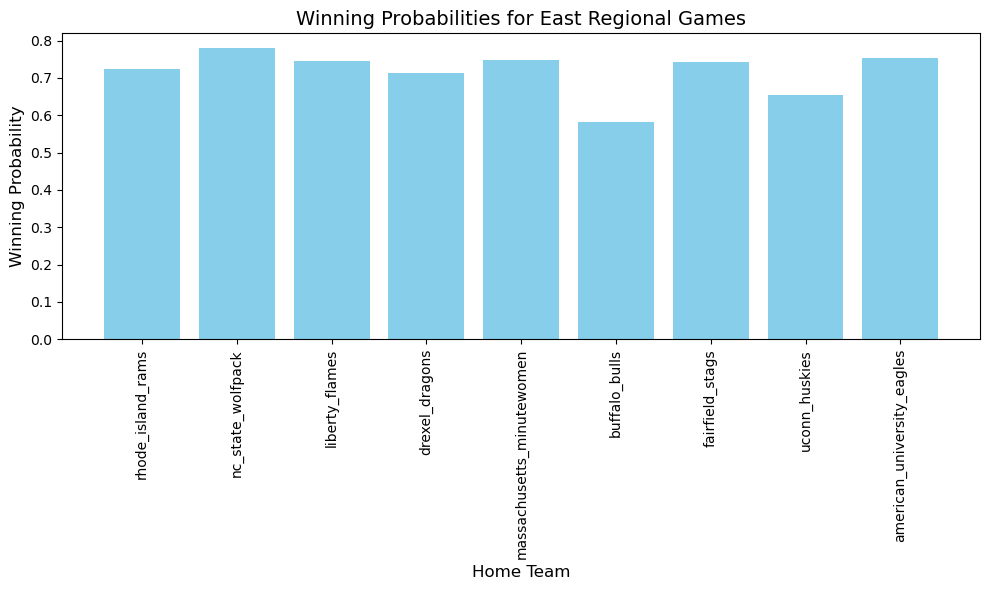

In [140]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

plt.bar(df_east_new['team_home'], df_east_new['win_probability'], color='skyblue')

plt.xlabel('Home Team', fontsize=12)
plt.ylabel('Winning Probability', fontsize=12)
plt.title('Winning Probabilities for East Regional Games', fontsize=14)
plt.xticks(rotation=90)  
plt.tight_layout()

plt.show()